In [1]:
!pip install -q PyPDF2 pandas numpy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.1 MB/s eta 0:00:00


In [2]:
import os
import re
import pandas as pd
import numpy as np

from PyPDF2 import PdfReader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [27]:
from google.colab import files

uploaded = files.upload()

Saving resume (5).pdf to resume (5).pdf


In [28]:
resume_file = list(uploaded.keys())[0]

reader = PdfReader(resume_file)

resume_text = ""

for page in reader.pages:
    text = page.extract_text()
    if text:
        resume_text += text + "\n"

print(resume_text[:5000])

1
ANIKET SHUKLA
7355278499 shukla1968.aniket@gmail.com github.com/7355-aniket
Mumbai, Maharashtra, India
PROFESSIONAL SUMMARY
Computer Science Engineering student with hands-on experience in AI/ML, software development, data analytics,
automation, and web development. Skilled in Python, Java, SQL, machine learning, computer vision, Flask, FastAPI,
and databases. Seeking Software Developer and AI/ML opportunities.
EDUCATION
B.Tech in Computer Science and Engineering2024–2028
Amity University Mumbai, Maharashtra, India
TECHNICAL SKILLS
Programming:Python, Java, C++, JavaScript, SQLAI/ML:TensorFlow, Keras, PyTorch, Scikit-learn, OpenCV,
YOLO
Web:HTML, CSS, React, Flask, FastAPI, REST APIsDatabase:MySQL, PostgreSQL, SQLite
Tools:Git, GitHub, VS Code, Jupyter, Google Colab, DockerCore:DSA, OOP, DBMS, Machine Learning
EXPERIENCE
WATNOT – Instant Delivery StartupJan 2024–Jun 2024
Cofounder – Inventory and Website Coordinator
•Managed inventory across 15+ stores with 98% accuracy and maintaine

In [5]:
job_description = """
We are looking for an AI/ML Intern.

Requirements:
Python
Machine Learning
TensorFlow
Keras
Scikit-learn
Pandas
NumPy
SQL
Computer Vision
Deep Learning

Responsibilities:
Develop machine learning models.
Process and analyze datasets.
Build computer vision applications.
Work with Python and TensorFlow.
Collaborate with software engineering teams.
"""

In [29]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

clean_resume = clean_text(resume_text)
clean_job = clean_text(job_description)

print(clean_resume[:1000])

1 aniket shukla 7355278499 shukla1968 aniket gmail com github com 7355 aniket mumbai maharashtra india professional summary computer science engineering student with hands on experience in ai ml software development data analytics automation and web development skilled in python java sql machine learning computer vision flask fastapi and databases seeking software developer and ai ml opportunities education b tech in computer science and engineering2024 2028 amity university mumbai maharashtra india technical skills programming python java c javascript sqlai ml tensorflow keras pytorch scikit learn opencv yolo web html css react flask fastapi rest apisdatabase mysql postgresql sqlite tools git github vs code jupyter google colab dockercore dsa oop dbms machine learning experience watnot instant delivery startupjan 2024 jun 2024 cofounder inventory and website coordinator managed inventory across 15 stores with 98 accuracy and maintained product availability managed website updates prod

In [30]:
vectorizer = TfidfVectorizer(
    stop_words="english"
)

vectors = vectorizer.fit_transform([
    clean_resume,
    clean_job
])

similarity = cosine_similarity(
    vectors[0:1],
    vectors[1:2]
)[0][0]

match_percentage = similarity * 100

print(f"Job Match Score: {match_percentage:.2f}%")

Job Match Score: 30.29%


In [31]:
skills = [
    "python",
    "java",
    "c++",
    "javascript",
    "sql",
    "machine learning",
    "deep learning",
    "artificial intelligence",
    "tensorflow",
    "keras",
    "pytorch",
    "scikit-learn",
    "pandas",
    "numpy",
    "opencv",
    "computer vision",
    "nlp",
    "flask",
    "fastapi",
    "django",
    "react",
    "docker",
    "aws",
    "git",
    "github",
    "mongodb",
    "mysql",
    "postgresql"
]

In [32]:
resume_skills = []

for skill in skills:
    if skill in clean_resume:
        resume_skills.append(skill)

print("Skills found in resume:")
for skill in resume_skills:
    print("✓", skill)

Skills found in resume:
✓ python
✓ java
✓ javascript
✓ sql
✓ machine learning
✓ tensorflow
✓ keras
✓ pytorch
✓ opencv
✓ computer vision
✓ nlp
✓ flask
✓ fastapi
✓ react
✓ docker
✓ git
✓ github
✓ mysql
✓ postgresql


In [33]:
job_skills = []

for skill in skills:
    if skill in clean_job:
        job_skills.append(skill)

print("Skills required by job:")
for skill in job_skills:
    print("•", skill)

Skills required by job:
• python
• sql
• machine learning
• deep learning
• tensorflow
• keras
• pandas
• numpy
• computer vision


In [34]:
missing_skills = []

for skill in job_skills:
    if skill not in resume_skills:
        missing_skills.append(skill)

print("Missing Skills:")

for skill in missing_skills:
    print("✗", skill)

Missing Skills:
✗ deep learning
✗ pandas
✗ numpy


In [35]:
if len(job_skills) > 0:
    skill_score = (
        len(set(resume_skills) & set(job_skills))
        / len(job_skills)
    ) * 100
else:
    skill_score = 0

print(f"Skill Match: {skill_score:.2f}%")

Skill Match: 66.67%


In [36]:
overall_score = (
    match_percentage * 0.4 +
    skill_score * 0.6
)

print(f"Overall Job Match Score: {overall_score:.2f}%")

Overall Job Match Score: 52.12%


In [37]:
print("\n===== JOB ANALYSIS =====")

print(f"\nOverall Match: {overall_score:.2f}%")

print("\nMatching Skills:")

matching_skills = list(
    set(resume_skills) & set(job_skills)
)

for skill in matching_skills:
    print("✓", skill)

print("\nMissing Skills:")

for skill in missing_skills:
    print("✗", skill)

print("\nRecommendations:")

if missing_skills:
    for skill in missing_skills:
        print(f"- Consider learning/improving {skill}")
else:
    print("- Your resume contains the main detected skills.")


===== JOB ANALYSIS =====

Overall Match: 52.12%

Matching Skills:
✓ keras
✓ computer vision
✓ tensorflow
✓ machine learning
✓ python
✓ sql

Missing Skills:
✗ deep learning
✗ pandas
✗ numpy

Recommendations:
- Consider learning/improving deep learning
- Consider learning/improving pandas
- Consider learning/improving numpy


In [38]:
company = "ABC Technologies"
role = "AI/ML Intern"

cover_letter = f"""
Dear Hiring Manager,

I am writing to apply for the {role} position at {company}.

I have experience working with Python, Machine Learning,
Deep Learning, TensorFlow, Keras, NumPy, Pandas and Computer Vision.
My projects have given me practical experience in developing
AI and machine learning applications.

After analyzing the job description, I found that my background
aligns with several of the technical requirements of this role.

I am interested in this opportunity because it would allow me
to apply my technical knowledge to real-world AI/ML problems
while continuing to develop my skills.

Thank you for considering my application.

Sincerely,
Applicant
"""

print(cover_letter)


Dear Hiring Manager,

I am writing to apply for the AI/ML Intern position at ABC Technologies.

I have experience working with Python, Machine Learning,
Deep Learning, TensorFlow, Keras, NumPy, Pandas and Computer Vision.
My projects have given me practical experience in developing
AI and machine learning applications.

After analyzing the job description, I found that my background
aligns with several of the technical requirements of this role.

I am interested in this opportunity because it would allow me
to apply my technical knowledge to real-world AI/ML problems
while continuing to develop my skills.

Thank you for considering my application.

Sincerely,
Applicant



In [39]:
applications = pd.DataFrame({
    "Company": [
        "ABC Technologies"
    ],
    "Role": [
        "AI/ML Intern"
    ],
    "Match Score": [
        round(overall_score, 2)
    ],
    "Status": [
        "Interested"
    ]
})

applications

,Company,Role,Match Score,Status
0,ABC Technologies,AI/ML Intern,52.12,Interested


In [17]:
new_application = {
    "Company": "JP MORGAN",
    "Role": "Machine Learning Intern",
    "Match Score": 84.5,
    "Status": "Applied"
}

applications.loc[len(applications)] = new_application

applications

,Company,Role,Match Score,Status
0,ABC Technologies,AI/ML Intern,54.4,Interested
1,JP MORGAN,Machine Learning Intern,84.5,Applied


In [18]:
applications.to_csv(
    "job_applications.csv",
    index=False
)

print("Application tracker saved!")

Application tracker saved!


In [24]:
new_application = {
    "Company": "google",
    "Role": "Machine Learning Intern",
    "Match Score": 82,
    "Status": "Applied"
}

applications.loc[len(applications)] = new_application

applications

,Company,Role,Match Score,Status
0,ABC Technologies,AI/ML Intern,54.4,Interested
1,JP MORGAN,Machine Learning Intern,84.5,Applied
2,google,Machine Learning Intern,84.5,Applied
3,MICRO SOFT,Machine Learning Intern,84.5,Applied
4,MICRO SOFT,Machine Learning Intern,80.0,Applied
5,google,Machine Learning Intern,82.0,Applied


In [23]:
new_application = {
    "Company": "MICRO SOFT",
    "Role": "Machine Learning Intern",
    "Match Score": 80,
    "Status": "Applied"
}

applications.loc[len(applications)] = new_application

applications

,Company,Role,Match Score,Status
0,ABC Technologies,AI/ML Intern,54.4,Interested
1,JP MORGAN,Machine Learning Intern,84.5,Applied
2,google,Machine Learning Intern,84.5,Applied
3,MICRO SOFT,Machine Learning Intern,84.5,Applied
4,MICRO SOFT,Machine Learning Intern,80.0,Applied


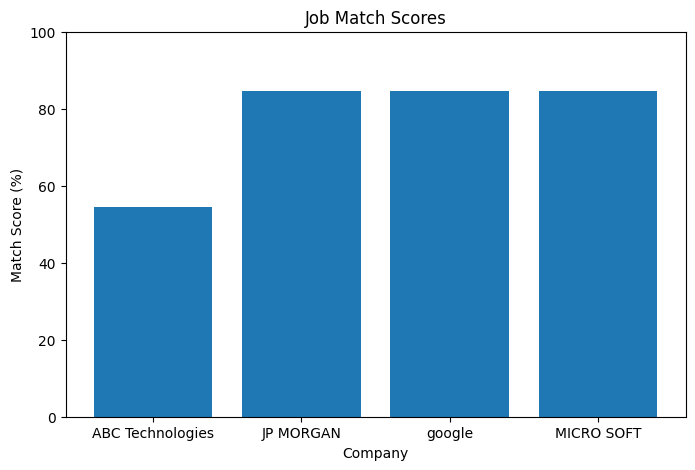

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    applications["Company"],
    applications["Match Score"]
)

plt.xlabel("Company")
plt.ylabel("Match Score (%)")
plt.title("Job Match Scores")

plt.ylim(0, 100)

plt.show()

In [26]:
def analyze_job(resume_text, job_description):

    resume = clean_text(resume_text)
    job = clean_text(job_description)

    vectorizer = TfidfVectorizer(
        stop_words="english"
    )

    vectors = vectorizer.fit_transform([
        resume,
        job
    ])

    similarity = cosine_similarity(
        vectors[0:1],
        vectors[1:2]
    )[0][0] * 100

    resume_skills = [
        skill for skill in skills
        if skill in resume
    ]

    job_skills = [
        skill for skill in skills
        if skill in job
    ]

    matching = list(
        set(resume_skills) & set(job_skills)
    )

    missing = list(
        set(job_skills) - set(resume_skills)
    )

    if job_skills:
        skill_score = (
            len(matching) / len(job_skills)
        ) * 100
    else:
        skill_score = 0

    overall = (
        similarity * 0.4 +
        skill_score * 0.6
    )

    return {
        "NLP Similarity": round(similarity, 2),
        "Skill Match": round(skill_score, 2),
        "Overall Score": round(overall, 2),
        "Matching Skills": matching,
        "Missing Skills": missing
    }